# Mode Dynamics Walkthrough

Goal: train a small network on `y = sin(x)` and check whether learning dynamics collapse into a low-dimensional set of update modes.

## 1) Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from mode_dynamics import (
    SineMLP,
    build_sine_dataset,
    train_with_tracking,
)

np.random.seed(0)
torch.manual_seed(0)

## 2) Dataset

In [2]:
n_samples = 5000
x_train, y_train = build_sine_dataset(
    n_samples=n_samples,
    seed=0,
)

print('Train:', x_train.shape, y_train.shape)

Train: torch.Size([5000, 1]) torch.Size([5000, 1])


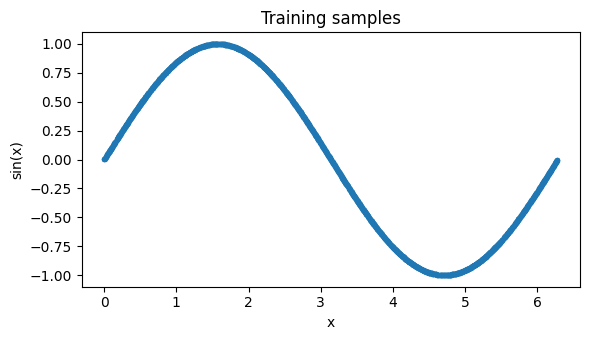

In [3]:
plt.figure(figsize=(6, 3.5))
plt.scatter(x_train.numpy(), y_train.numpy(), s=8, alpha=0.45)
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.title('Training samples')
plt.tight_layout()
plt.show()

## 3) Model

In [4]:
hidden_dim = 2
model = SineMLP(hidden_dim=hidden_dim)
print(model)
print('Total params:', sum(p.numel() for p in model.parameters()))

SineMLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=2, bias=True)
    (1): Tanh()
    (2): Linear(in_features=2, out_features=1, bias=True)
  )
)
Total params: 7


## 4) Train and track dynamics

In [5]:
snapshot_epochs = [1000, 5000, 10000, 20000, 40000, 80000]
tracked = train_with_tracking(
    model=model,
    x_train=x_train,
    y_train=y_train,
    n_epochs=80000,
    lr=0.01,
    checkpoint_every=10,
    snapshot_epochs=snapshot_epochs,
)

train_losses = tracked['train_losses']
checkpoint_epochs = tracked['checkpoint_epochs']
weight_matrix = tracked['checkpoint_weights']
snapshots = tracked['snapshots']

print('Training complete')
print('Weight matrix shape:', weight_matrix.shape)

Training complete
Weight matrix shape: (8001, 7)


## 5) Loss curve

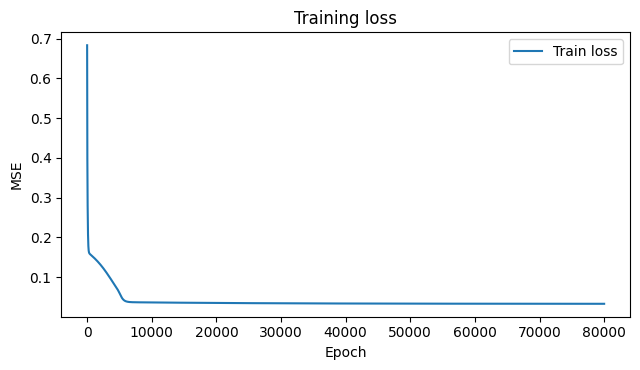

In [6]:
epochs = np.arange(1, len(train_losses) + 1)
plt.figure(figsize=(6.5, 3.8))
plt.plot(epochs, train_losses, label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training loss')
plt.legend()
plt.tight_layout()
plt.show()

## 6) Function predictions over time

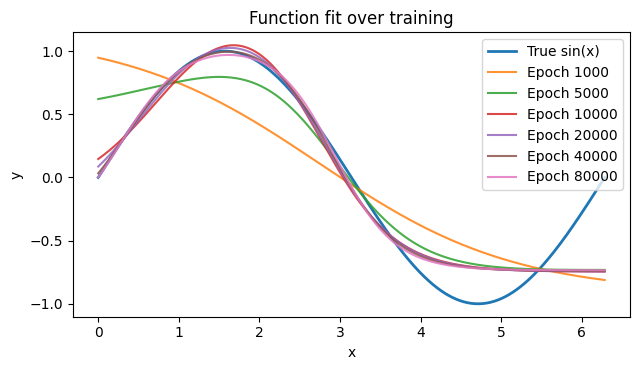

In [7]:
x_plot = torch.linspace(0.0, 2.0 * np.pi, 400).view(-1, 1)
y_true = torch.sin(x_plot).numpy()

plt.figure(figsize=(6.5, 3.8))
plt.plot(x_plot.numpy(), y_true, label='True sin(x)', linewidth=2)
for ep in snapshot_epochs:
    temp_model = SineMLP(hidden_dim=hidden_dim)
    temp_model.load_state_dict(snapshots[ep])
    temp_model.eval()
    with torch.no_grad():
        y_pred = temp_model(x_plot).numpy()
    plt.plot(x_plot.numpy(), y_pred, label=f'Epoch {ep}', alpha=0.85)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Function fit over training')
plt.legend()
plt.tight_layout()
plt.show()

## 7) Unified dynamics overview

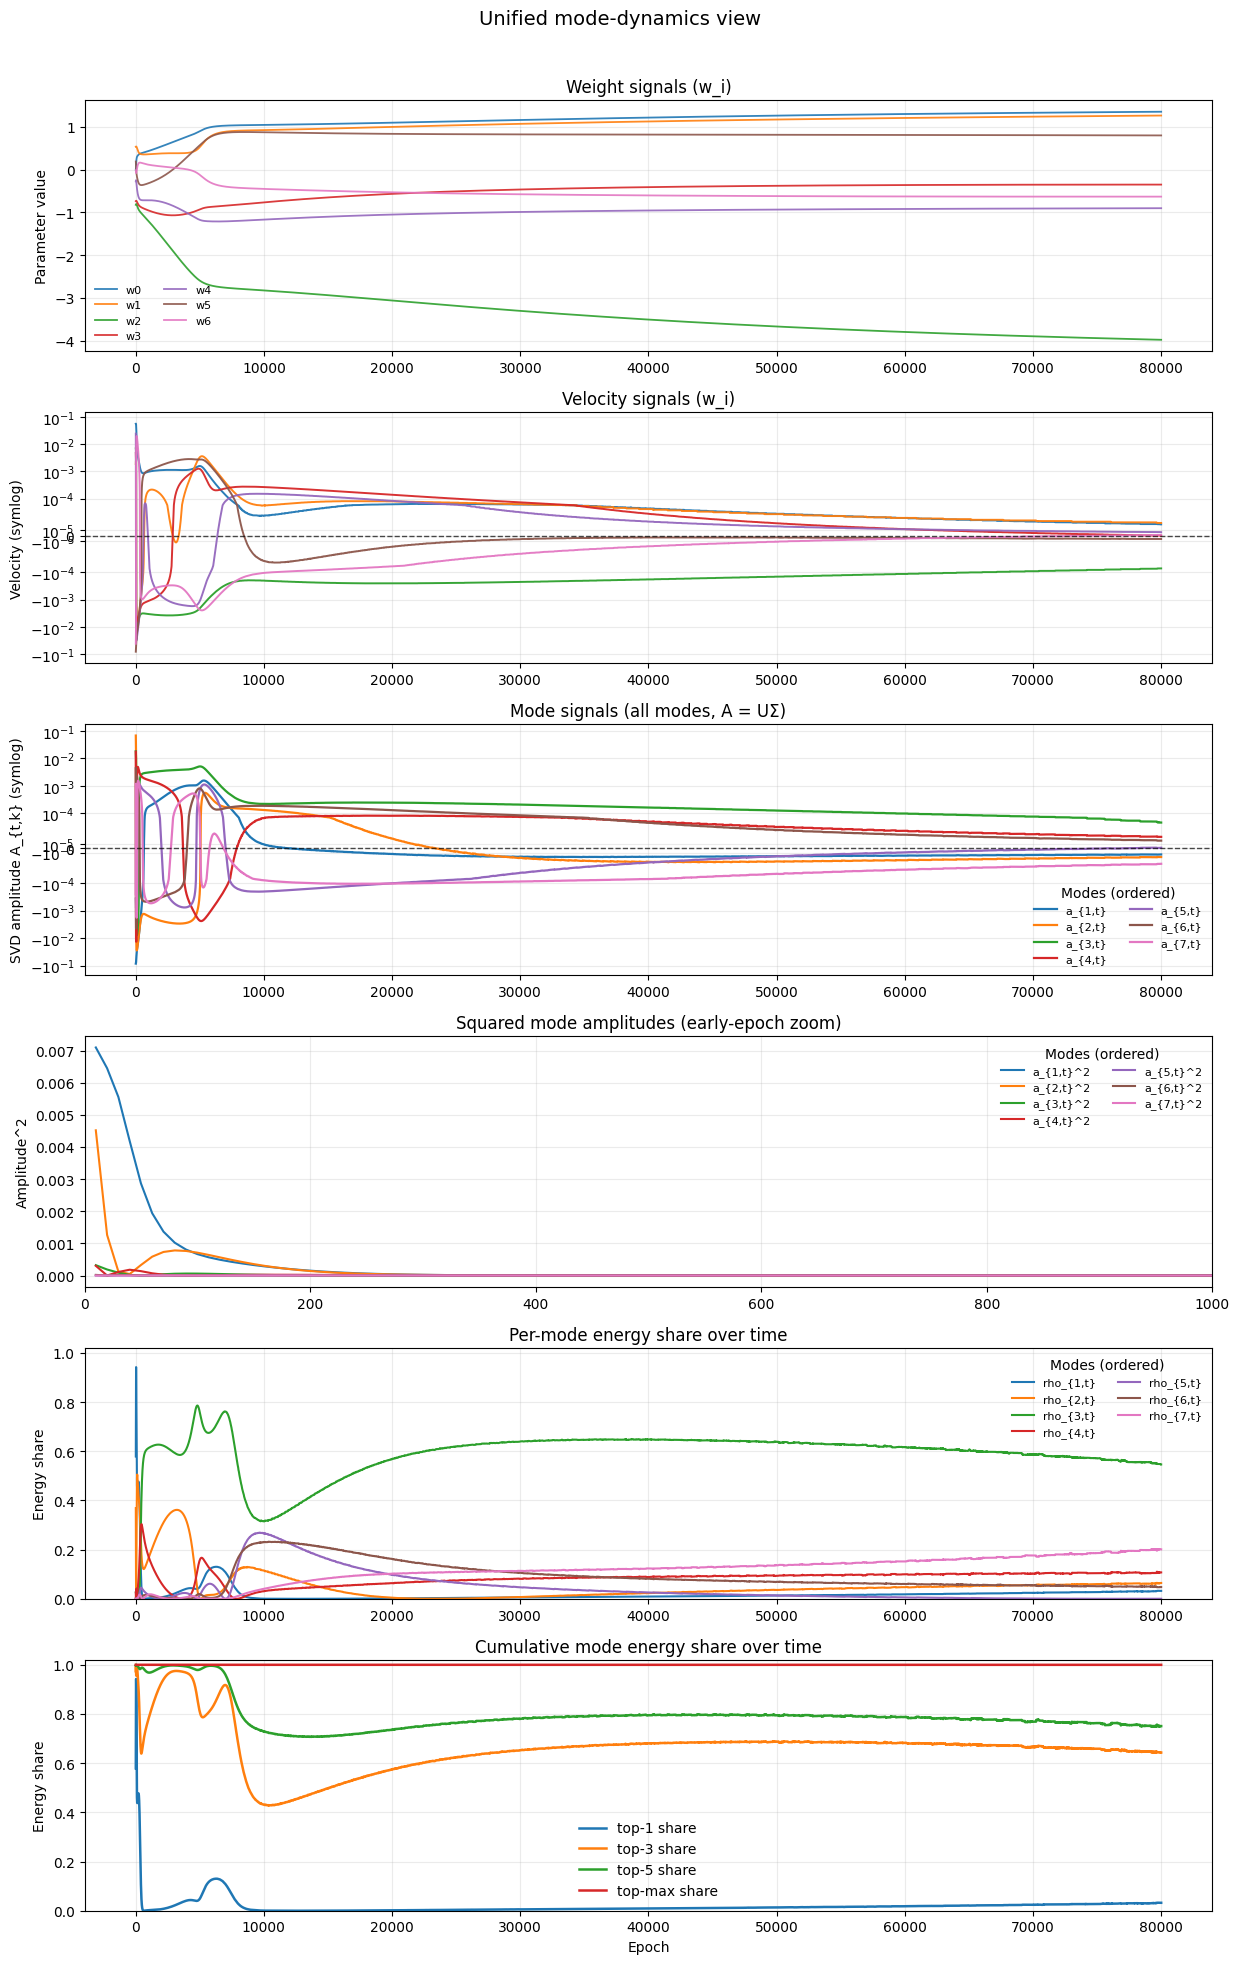

In [8]:
# Compute velocity matrix and mode coefficients
velocity_matrix = np.diff(weight_matrix, axis=0)  # shape: (num_checkpoints-1, num_params)
velocity_epochs = checkpoint_epochs[1:]

_u_time, _s_vals, vh_modes = np.linalg.svd(velocity_matrix, full_matrices=False)
n_modes = vh_modes.shape[0]
mode_coeffs_all = velocity_matrix @ vh_modes.T  # shape: (num_steps, n_modes)

# Mode energy share: rho_{k,t} = a_{k,t}^2 / sum_j a_{j,t}^2
energy_total = np.sum(mode_coeffs_all**2, axis=1) + 1e-12
rho_all = (mode_coeffs_all**2) / energy_total[:, None]

# Cumulative top-K shares (up to top-max)
k_candidates = [1, 3, 5, 10, n_modes]
k_values = []
for k in k_candidates:
    k_clamped = min(k, n_modes)
    if k_clamped not in k_values:
        k_values.append(k_clamped)

# Consistent color mapping for flattened coordinates w_i
n_weights = weight_matrix.shape[1]
weight_colors = {i: plt.cm.tab10(i % 10) for i in range(n_weights)}
weight_labels = {i: f'w{i}' for i in range(n_weights)}
mode_colors = [plt.cm.tab10(k % 10) for k in range(n_modes)]

fig, axes = plt.subplots(6, 1, figsize=(12.5, 20.0), sharex=False)

# (1) Weight signals
ax = axes[0]
for i in range(n_weights):
    ax.plot(
        checkpoint_epochs,
        weight_matrix[:, i],
        color=weight_colors[i],
        alpha=0.9,
        linewidth=1.3,
        label=weight_labels[i],
    )
ax.set_ylabel('Parameter value')
ax.set_title('Weight signals (w_i)')
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8, frameon=False)

# (2) Velocity signals (symlog)
ax = axes[1]
for i in range(n_weights):
    ax.plot(
        velocity_epochs,
        velocity_matrix[:, i],
        color=weight_colors[i],
        alpha=0.95,
        linewidth=1.4,
    )
vel_linthresh = max(1e-6, np.quantile(np.abs(velocity_matrix), 0.60))
ax.set_yscale('symlog', linthresh=vel_linthresh, linscale=1.0, base=10)
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
ax.set_ylabel('Velocity (symlog)')
ax.set_title('Velocity signals (w_i)')
ax.grid(alpha=0.25, which='both')

# (3) Mode signals (all modes, color-coded)
ax = axes[2]
for k in range(n_modes):
    ax.plot(
        velocity_epochs,
        mode_coeffs_all[:, k],
        label=f'a_{{{k+1},t}}',
        linewidth=1.6,
        color=mode_colors[k],
    )
mode_linthresh = max(1e-8, np.quantile(np.abs(mode_coeffs_all), 0.60))
ax.set_yscale('symlog', linthresh=mode_linthresh, linscale=1.0, base=10)
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
ax.set_ylabel('SVD amplitude A_{t,k} (symlog)')
ax.set_title('Mode signals (all modes, A = UΣ)')
ax.grid(alpha=0.25, which='both')
ax.legend(title='Modes (ordered)', ncol=2, fontsize=8, frameon=False)

# (4) Squared mode amplitudes a_{k,t}^2 (early-epoch zoom)
ax = axes[3]
for k in range(n_modes):
    ax.plot(
        velocity_epochs,
        mode_coeffs_all[:, k] ** 2,
        color=mode_colors[k],
        linewidth=1.5,
        label=f'a_{{{k+1},t}}^2',
    )
early_epoch_max = 1000
ax.set_xlim(0, early_epoch_max)
ax.set_ylabel('Amplitude^2')
ax.set_title('Squared mode amplitudes (early-epoch zoom)')
ax.grid(alpha=0.25, which='both')
ax.legend(title='Modes (ordered)', ncol=2, fontsize=8, frameon=False)

# (5) Per-mode energy share signals
ax = axes[4]
for k in range(n_modes):
    ax.plot(
        velocity_epochs,
        rho_all[:, k],
        color=mode_colors[k],
        linewidth=1.5,
        label=f'rho_{{{k+1},t}}',
    )
ax.set_ylabel('Energy share')
ax.set_ylim(0.0, 1.02)
ax.set_title('Per-mode energy share over time')
ax.grid(alpha=0.25)
ax.legend(title='Modes (ordered)', ncol=2, fontsize=8, frameon=False)

# (6) Cumulative top-n energy share signals
ax = axes[5]
for k in k_values:
    share_k = np.sum(rho_all[:, :k], axis=1)
    label = f'top-{k} share' if k < n_modes else 'top-max share'
    ax.plot(velocity_epochs, share_k, linewidth=1.8, label=label)

ax.set_xlabel('Epoch')
ax.set_ylabel('Energy share')
ax.set_ylim(0.0, 1.02)
ax.set_title('Cumulative mode energy share over time')
ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig.suptitle('Unified mode-dynamics view', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## 8) Time-dependent mode-to-function mapping

Compute $\phi_k(x,t)$ at selected checkpoints and compare actual output change against mode-based reconstruction over one checkpoint step.

One-step Delta f reconstruction (time-dependent phi_k):
Available modes: recon_k = 7
Components: ['a_1', 'a_2', 'a_3', 'a_4', 'a_5', 'a_6', 'a_7']
K levels: [1, 3, 5, 7]
epoch | R2@top-1 | R2@top-3 | R2@top-5 | R2@top-7
 1000 | -1.3166 | -41.0734 | -0.0225 | 0.9998
 5000 | -1.7803 | -0.4448 | 0.3554 | 0.9999
10000 | -0.3183 | -96.9409 | -91.6773 | 0.9998
20000 | -2.3284 | -135.7404 | -100.5884 | 0.9998
40000 | -16.6230 | -139.6826 | -80.1804 | 0.9998


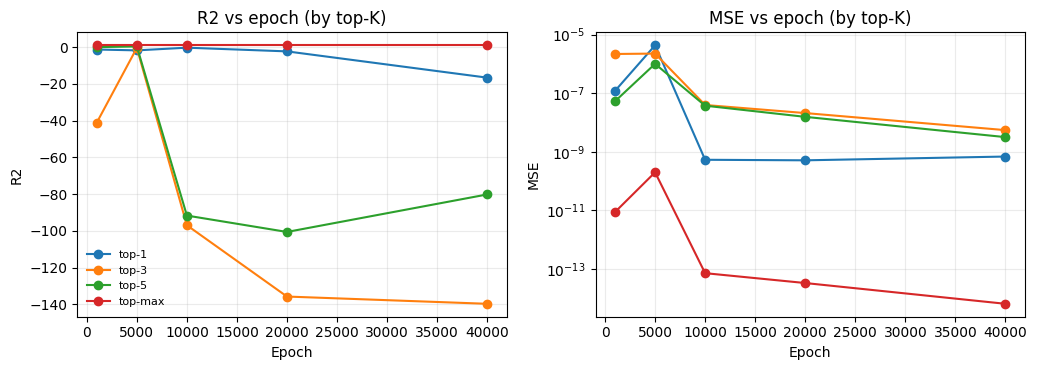

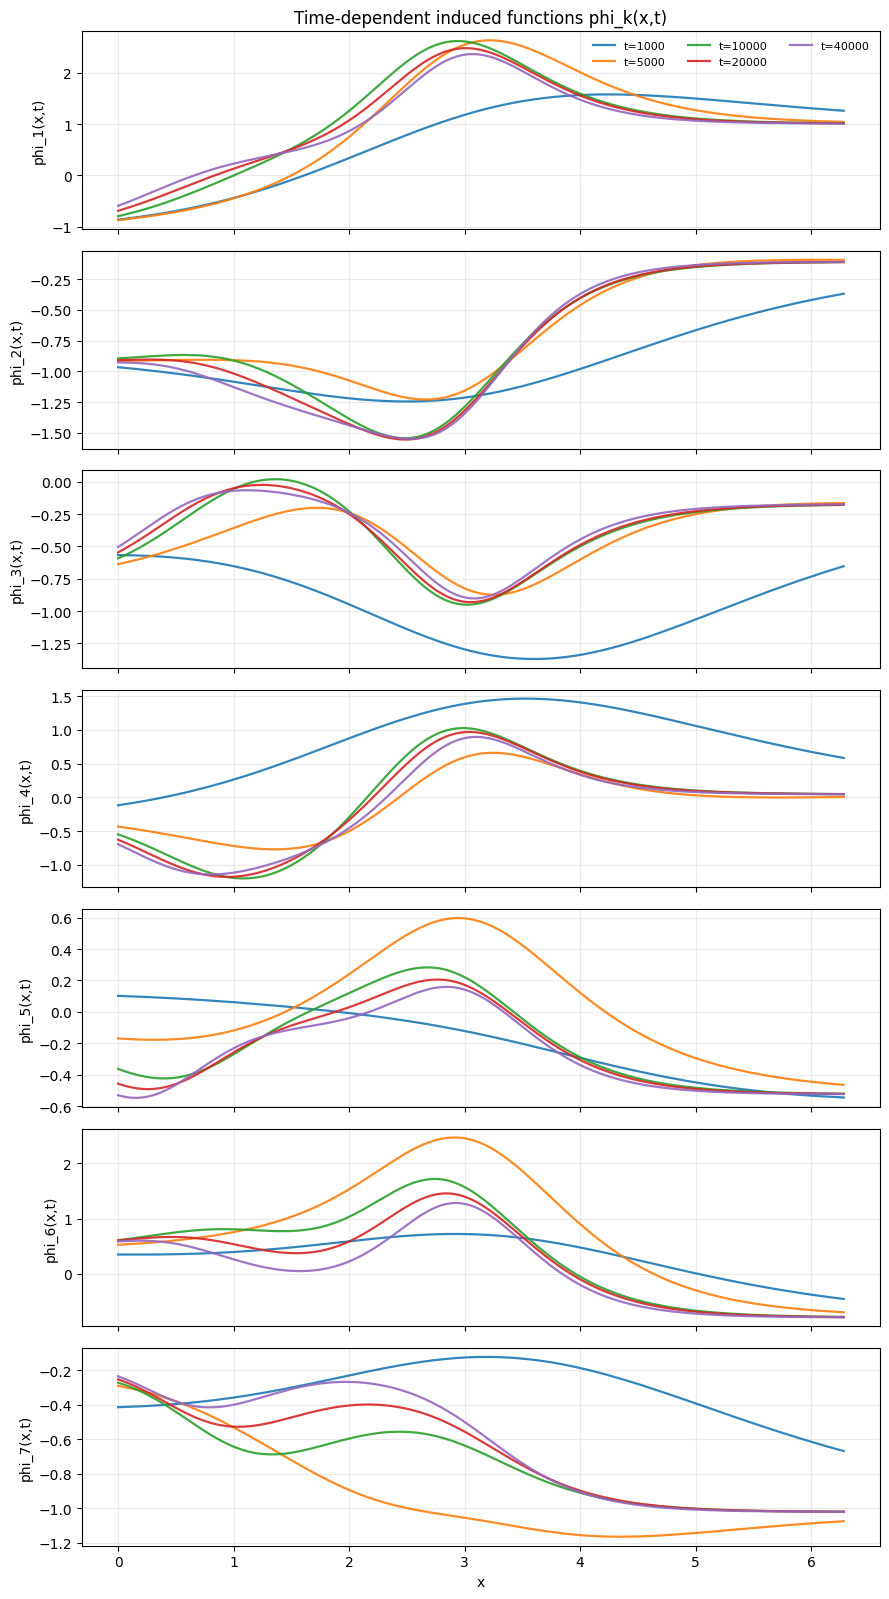

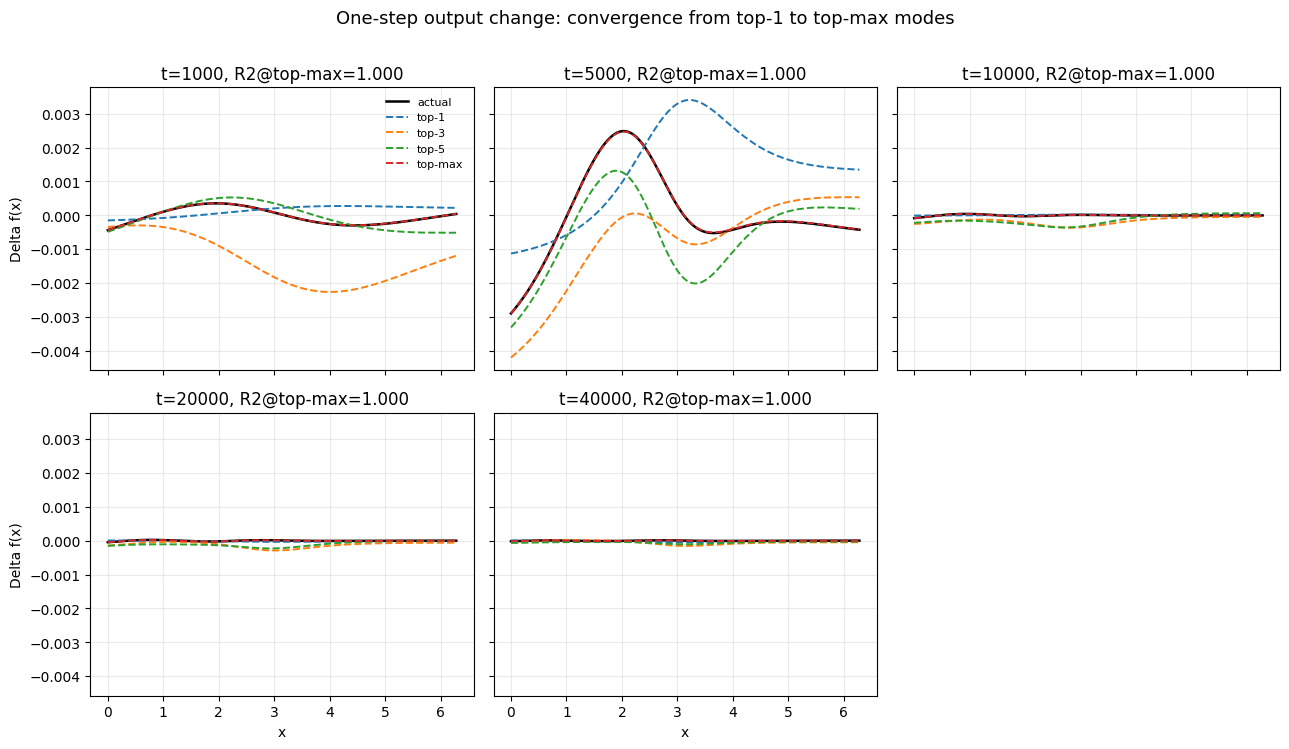

In [9]:
# Time-dependent phi_k(x,t) and one-step Delta f reconstruction

checkpoint_every = int(checkpoint_epochs[1] - checkpoint_epochs[0])
selected_epochs = [1000, 5000, 10000, 20000, 40000, 80000]
selected_epochs = [ep for ep in selected_epochs if ep in set(checkpoint_epochs[:-1])]

x_grid = torch.linspace(0.0, 2.0 * np.pi, 400).view(-1, 1)
recon_k = vh_modes.shape[0]  # use all available modes (limit case)
epsilon = 1e-3

k_eval_values = [1, 3, 5, recon_k]
k_eval_values = sorted(set(min(k, recon_k) for k in k_eval_values))


def load_flat_params_(model, flat_vector):
    """Load a flattened parameter vector back into model parameters."""
    offset = 0
    with torch.no_grad():
        for p in model.parameters():
            n = p.numel()
            block = torch.from_numpy(flat_vector[offset : offset + n]).to(p.dtype).view_as(p)
            p.copy_(block)
            offset += n


def predict_from_flat(flat_vector, hidden_dim, x_eval):
    m = SineMLP(hidden_dim=hidden_dim)
    load_flat_params_(m, flat_vector)
    m.eval()
    with torch.no_grad():
        y = m(x_eval).cpu().numpy().squeeze()
    return y


selected_results = []
for ep in selected_epochs:
    idx = int(np.where(checkpoint_epochs == ep)[0][0])

    theta_t = weight_matrix[idx]
    theta_next = weight_matrix[idx + 1]

    # Actual function change over one checkpoint step
    f_t = predict_from_flat(theta_t, hidden_dim=hidden_dim, x_eval=x_grid)
    f_next = predict_from_flat(theta_next, hidden_dim=hidden_dim, x_eval=x_grid)
    delta_actual = f_next - f_t

    # Time-local mode amplitudes for this transition t -> t+1
    a_t = mode_coeffs_all[idx, :recon_k]

    # Time-dependent induced functions phi_k(x,t) via finite differences
    phis_t = []
    for k in range(recon_k):
        u_k = vh_modes[k]  # parameter-space mode direction
        f_plus = predict_from_flat(theta_t + epsilon * u_k, hidden_dim=hidden_dim, x_eval=x_grid)
        phi_k_t = (f_plus - f_t) / epsilon
        phis_t.append(phi_k_t)

    phis_t = np.stack(phis_t, axis=0)  # shape: (recon_k, n_x)

    # Reconstruction quality at different top-K truncations
    var = float(np.var(delta_actual) + 1e-12)
    recon_by_k = {}
    for k_use in k_eval_values:
        delta_pred_k = np.sum(a_t[:k_use, None] * phis_t[:k_use], axis=0)
        mse_k = float(np.mean((delta_actual - delta_pred_k) ** 2))
        r2_k = float(1.0 - mse_k / var)
        recon_by_k[k_use] = {
            'delta_pred': delta_pred_k,
            'mse': mse_k,
            'r2': r2_k,
        }

    selected_results.append(
        {
            'epoch': ep,
            'a_t': a_t,
            'phis_t': phis_t,
            'delta_actual': delta_actual,
            'recon_by_k': recon_by_k,
        }
    )

# Print compact metrics
print('One-step Delta f reconstruction (time-dependent phi_k):')
print(f'Available modes: recon_k = {recon_k}')
print('Components:', [f'a_{k+1}' for k in range(recon_k)])
print('K levels:', k_eval_values)

header = 'epoch | ' + ' | '.join([f'R2@top-{k}' for k in k_eval_values])
print(header)
for r in selected_results:
    r2_parts = [f"{r['recon_by_k'][k]['r2']:.4f}" for k in k_eval_values]
    print(f"{r['epoch']:>5d} | " + ' | '.join(r2_parts))

# Error metrics vs epoch for each top-K truncation
epochs_arr = np.array([r['epoch'] for r in selected_results])

fig, axes_metrics = plt.subplots(1, 2, figsize=(10.5, 3.8), sharex=True)
for i, k in enumerate(k_eval_values):
    color = plt.cm.tab10(i % 10)
    label = f'top-{k}' if k < recon_k else 'top-max'
    r2_vals = [r['recon_by_k'][k]['r2'] for r in selected_results]
    mse_vals = [r['recon_by_k'][k]['mse'] for r in selected_results]

    axes_metrics[0].plot(epochs_arr, r2_vals, marker='o', linewidth=1.5, color=color, label=label)
    axes_metrics[1].plot(epochs_arr, mse_vals, marker='o', linewidth=1.5, color=color, label=label)

axes_metrics[0].set_title('R2 vs epoch (by top-K)')
axes_metrics[0].set_xlabel('Epoch')
axes_metrics[0].set_ylabel('R2')
axes_metrics[0].grid(alpha=0.25)
axes_metrics[0].legend(frameon=False, fontsize=8)

axes_metrics[1].set_title('MSE vs epoch (by top-K)')
axes_metrics[1].set_xlabel('Epoch')
axes_metrics[1].set_ylabel('MSE')
axes_metrics[1].set_yscale('log')
axes_metrics[1].grid(alpha=0.25, which='both')

plt.tight_layout()
plt.show()

# Plot phi_k(x,t) at each selected epoch for all reconstruction modes
fig, axes = plt.subplots(recon_k, 1, figsize=(9.0, 2.3 * recon_k), sharex=True)
if recon_k == 1:
    axes = [axes]
for k in range(recon_k):
    ax = axes[k]
    for r in selected_results:
        ax.plot(x_grid.numpy().squeeze(), r['phis_t'][k], label=f"t={r['epoch']}", linewidth=1.6, alpha=0.9)
    ax.set_ylabel(f"phi_{k+1}(x,t)")
    ax.grid(alpha=0.25)
    if k == 0:
        ax.set_title('Time-dependent induced functions phi_k(x,t)')
    if k == recon_k - 1:
        ax.set_xlabel('x')

axes[0].legend(ncol=3, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

# Plot actual vs reconstructed Delta f for selected epochs (top-1/top-3/top-5/top-max)
n_plots = len(selected_results)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13.0, 3.8 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(n_rows, n_cols)

k_colors = {k: plt.cm.tab10(i % 10) for i, k in enumerate(k_eval_values)}

for i, r in enumerate(selected_results):
    rr, cc = divmod(i, n_cols)
    ax = axes[rr, cc]
    x_np = x_grid.numpy().squeeze()

    ax.plot(x_np, r['delta_actual'], color='black', linewidth=1.8, label='actual')
    for k in k_eval_values:
        yk = r['recon_by_k'][k]['delta_pred']
        label = f'top-{k}' if k < recon_k else 'top-max'
        ax.plot(x_np, yk, linewidth=1.4, linestyle='--', color=k_colors[k], label=label)

    r2_topmax = r['recon_by_k'][k_eval_values[-1]]['r2']
    ax.set_title(f"t={r['epoch']}, R2@top-max={r2_topmax:.3f}")
    ax.grid(alpha=0.25)

for j in range(n_plots, n_rows * n_cols):
    rr, cc = divmod(j, n_cols)
    axes[rr, cc].axis('off')

axes[0, 0].legend(frameon=False, fontsize=8)
for rr in range(n_rows):
    axes[rr, 0].set_ylabel('Delta f(x)')
for cc in range(n_cols):
    axes[-1, cc].set_xlabel('x')

fig.suptitle('One-step output change: convergence from top-1 to top-max modes', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 9) Absolute prediction via path-integrated top-K updates

Path-integrated absolute prediction reconstruction (top-K)
Max evaluated epoch: 80000, modes: 7
K levels: [1, 3, 5, 7]
epoch | R2@top-1 | R2@top-3 | R2@top-5 | R2@top-7
  200 | 0.7549 | 0.9986 | 0.9985 | 0.9981
  500 | 0.5940 | 0.9835 | 0.9981 | 0.9988
 1000 | 0.6040 | 0.9323 | 0.9981 | 0.9989
 2000 | 0.6325 | 0.7983 | 0.9974 | 0.9989
 5000 | 0.5739 | 0.8226 | 0.9875 | 0.9989
10000 | 0.2780 | 0.7125 | 0.9821 | 0.9984
20000 | 0.2797 | 0.4375 | 0.9230 | 0.9922
40000 | 0.2818 | 0.0966 | 0.8284 | 0.9918
60000 | 0.2828 | -0.6278 | 0.6764 | 0.8966
80000 | 0.2834 | -0.6674 | 0.6333 | 0.8976


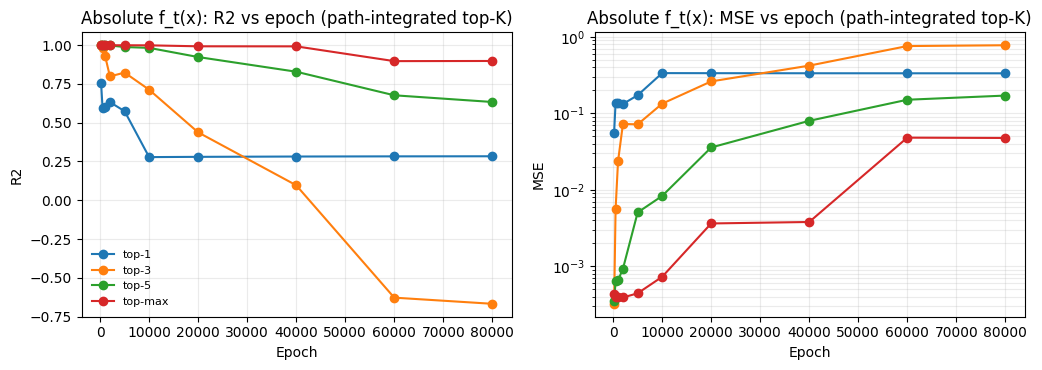

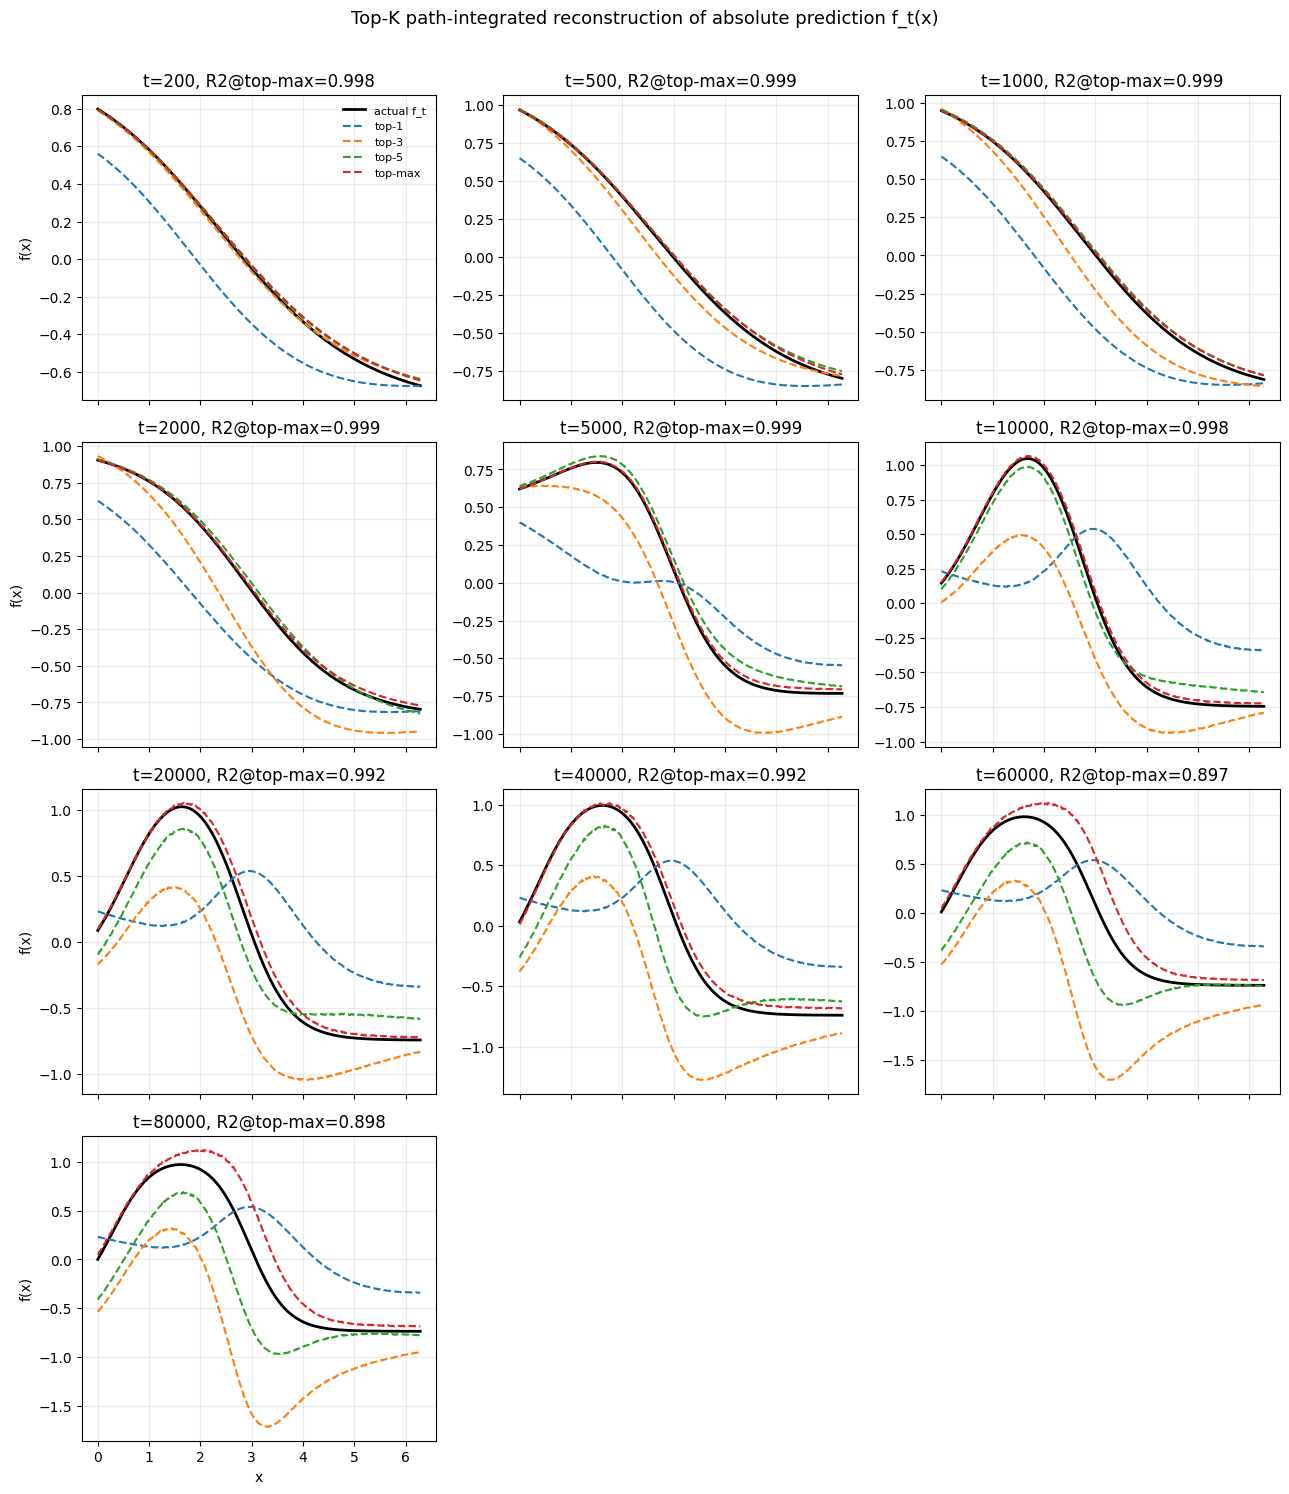

In [10]:
# Path-integrated absolute reconstruction:
# f_t(x) = f_0(x) + sum_{tau=0}^{t-1} Delta f_tau(x)
# Delta f_tau(x) approx sum_k a_{k,tau} * phi_k(x, theta_tau)

selected_epochs_abs_candidates = [
    200, 500, 1000, 2000, 5000, 10000, 20000, 40000, 60000, 80000
]
selected_epochs_abs = [ep for ep in selected_epochs_abs_candidates if ep in set(checkpoint_epochs)]

if len(selected_epochs_abs) == 0:
    raise ValueError('No selected epochs found in checkpoint_epochs.')

u_modes = vh_modes
n_modes_abs = u_modes.shape[0]

epsilon_abs = float(epsilon if 'epsilon' in globals() else 1e-3)

k_abs_values = [1, 3, 5, n_modes_abs]
k_abs_values = sorted(set(min(k, n_modes_abs) for k in k_abs_values))

epoch_to_idx = {int(ep): int(i) for i, ep in enumerate(checkpoint_epochs)}
max_idx = max(epoch_to_idx[int(ep)] for ep in selected_epochs_abs)

# Reuse one model instance in long loops
_work_model = SineMLP(hidden_dim=hidden_dim)


def predict_from_flat_fast(flat_vector, x_eval):
    load_flat_params_(_work_model, flat_vector)
    _work_model.eval()
    with torch.no_grad():
        y = _work_model(x_eval).cpu().numpy().squeeze()
    return y


# f(theta_t) for checkpoints up to max selected epoch
f_checkpoints = []
for idx in range(max_idx + 1):
    f_checkpoints.append(predict_from_flat_fast(weight_matrix[idx], x_grid))
f_checkpoints = np.stack(f_checkpoints, axis=0)  # (max_idx + 1, n_x)

f0 = f_checkpoints[0]
n_steps = max_idx
n_x = f_checkpoints.shape[1]

# One-step top-K mode reconstructions
step_delta_pred_by_k = {k: np.zeros((n_steps, n_x), dtype=np.float64) for k in k_abs_values}

for tau in range(n_steps):
    theta_tau = weight_matrix[tau]
    f_tau = f_checkpoints[tau]
    a_tau = mode_coeffs_all[tau]  # coefficients of v_tau in mode basis

    for k_use in k_abs_values:
        # Truncated update in mode basis: v_tau^(K)
        dtheta_k = a_tau[:k_use] @ u_modes[:k_use]
        f_plus = predict_from_flat_fast(theta_tau + epsilon_abs * dtheta_k, x_grid)
        step_delta_pred_by_k[k_use][tau] = (f_plus - f_tau) / epsilon_abs

# Prefix cumulative sums for direct lookup at epoch index
cum_pred_by_k = {}
for k_use in k_abs_values:
    csum = np.cumsum(step_delta_pred_by_k[k_use], axis=0)
    cum_pred_by_k[k_use] = np.vstack([np.zeros((1, n_x)), csum])

abs_results = []
for ep in selected_epochs_abs:
    idx = epoch_to_idx[int(ep)]
    f_t = f_checkpoints[idx]

    var_t = float(np.var(f_t) + 1e-12)
    recon_by_k = {}
    for k_use in k_abs_values:
        f_hat_k = f0 + cum_pred_by_k[k_use][idx]
        mse_k = float(np.mean((f_t - f_hat_k) ** 2))
        r2_k = float(1.0 - mse_k / var_t)
        recon_by_k[k_use] = {
            'f_hat': f_hat_k,
            'mse': mse_k,
            'r2': r2_k,
        }

    abs_results.append(
        {
            'epoch': int(ep),
            'f_t': f_t,
            'recon_by_k': recon_by_k,
        }
    )

print('Path-integrated absolute prediction reconstruction (top-K)')
print(f'Max evaluated epoch: {selected_epochs_abs[-1]}, modes: {n_modes_abs}')
print('K levels:', k_abs_values)
header = 'epoch | ' + ' | '.join([f'R2@top-{k}' for k in k_abs_values])
print(header)
for r in abs_results:
    r2_parts = [f"{r['recon_by_k'][k]['r2']:.4f}" for k in k_abs_values]
    print(f"{r['epoch']:>5d} | " + ' | '.join(r2_parts))

# Metrics vs epoch
epochs_abs = np.array([r['epoch'] for r in abs_results])
fig, axes_metrics = plt.subplots(1, 2, figsize=(10.5, 3.8), sharex=True)
for i, k in enumerate(k_abs_values):
    color = plt.cm.tab10(i % 10)
    label = f'top-{k}' if k < n_modes_abs else 'top-max'

    r2_vals = [r['recon_by_k'][k]['r2'] for r in abs_results]
    mse_vals = [r['recon_by_k'][k]['mse'] for r in abs_results]

    axes_metrics[0].plot(epochs_abs, r2_vals, marker='o', linewidth=1.5, color=color, label=label)
    axes_metrics[1].plot(epochs_abs, mse_vals, marker='o', linewidth=1.5, color=color, label=label)

axes_metrics[0].set_title('Absolute f_t(x): R2 vs epoch (path-integrated top-K)')
axes_metrics[0].set_xlabel('Epoch')
axes_metrics[0].set_ylabel('R2')
axes_metrics[0].grid(alpha=0.25)
axes_metrics[0].legend(frameon=False, fontsize=8)

axes_metrics[1].set_title('Absolute f_t(x): MSE vs epoch (path-integrated top-K)')
axes_metrics[1].set_xlabel('Epoch')
axes_metrics[1].set_ylabel('MSE')
axes_metrics[1].set_yscale('log')
axes_metrics[1].grid(alpha=0.25, which='both')

plt.tight_layout()
plt.show()

# Overlay plots: actual vs top-K path-integrated reconstructions
n_plots = len(abs_results)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13.0, 3.8 * n_rows), sharex=True)
axes = np.array(axes).reshape(n_rows, n_cols)

k_line_colors = {k: plt.cm.tab10(i % 10) for i, k in enumerate(k_abs_values)}

x_np = x_grid.numpy().squeeze()
for i, r in enumerate(abs_results):
    rr, cc = divmod(i, n_cols)
    ax = axes[rr, cc]

    ax.plot(x_np, r['f_t'], color='black', linewidth=2.0, label='actual f_t')

    for k in k_abs_values:
        label = f'top-{k}' if k < n_modes_abs else 'top-max'
        ax.plot(
            x_np,
            r['recon_by_k'][k]['f_hat'],
            linestyle='--',
            linewidth=1.5,
            color=k_line_colors[k],
            label=label,
        )

    r2_topmax = r['recon_by_k'][k_abs_values[-1]]['r2']
    ax.set_title(f"t={r['epoch']}, R2@top-max={r2_topmax:.3f}")
    ax.grid(alpha=0.25)

for j in range(n_plots, n_rows * n_cols):
    rr, cc = divmod(j, n_cols)
    axes[rr, cc].axis('off')

axes[0, 0].legend(frameon=False, fontsize=8)
for rr in range(n_rows):
    axes[rr, 0].set_ylabel('f(x)')
for cc in range(n_cols):
    axes[-1, cc].set_xlabel('x')

fig.suptitle('Top-K path-integrated reconstruction of absolute prediction f_t(x)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [11]:
# End of walkthrough.
